# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [144]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

In [145]:
# ⭐ helper functions with descriptions ⭐
def convert_to_proper_format(array: np.ndarray) -> np.ndarray:
    """ Convert the image from BGR to RGB or RGBA or leave it as grayscale """
    print(img_bgr.shape) # first check the shape of the image

    if array.ndim == 3 and array.shape[2] == 4:
        print('converting BGRA to RGBA')
        return cv2.cvtColor(array, cv2.COLOR_BGRA2RGBA)
    elif array.ndim == 3 and array.shape[2] == 3:
        print('converting BGR to RGB')
        return cv2.cvtColor(array, cv2.COLOR_BGR2RGB)
    else:
        print('grayscale image')
        return array

(846, 1500, 3)
converting BGR to RGB


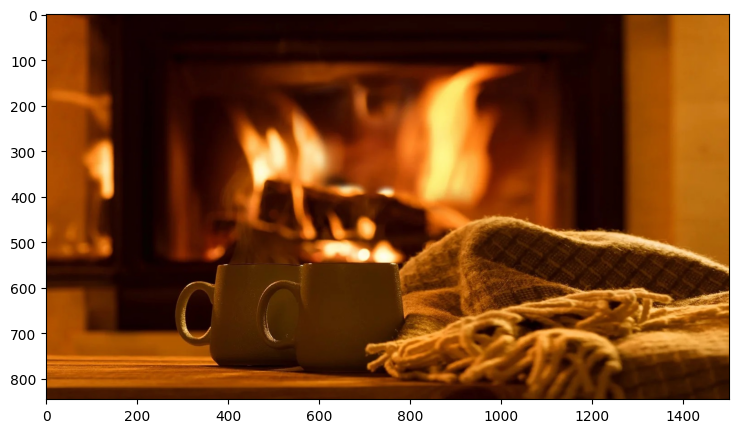

In [148]:
# img_bgr = cv2.imread('../data/sea.jpg') # - Original image
# img_bgr = cv2.imread('../data/lion-bw-animals-predator-preview.jpg') # - black and white image
# img_bgr = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg') # - beautiful landscape
# img_bgr = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg') # - another beautiful landscape
# img_bgr = cv2.imread('../data/owl.png') # - owl taken by my phone x100 zoom
img_bgr = cv2.imread('../data/cocoa+fireside.jpg') # Let's work with this one

img = convert_to_proper_format(img_bgr)

plt.imshow(img)


### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x23505619890>)

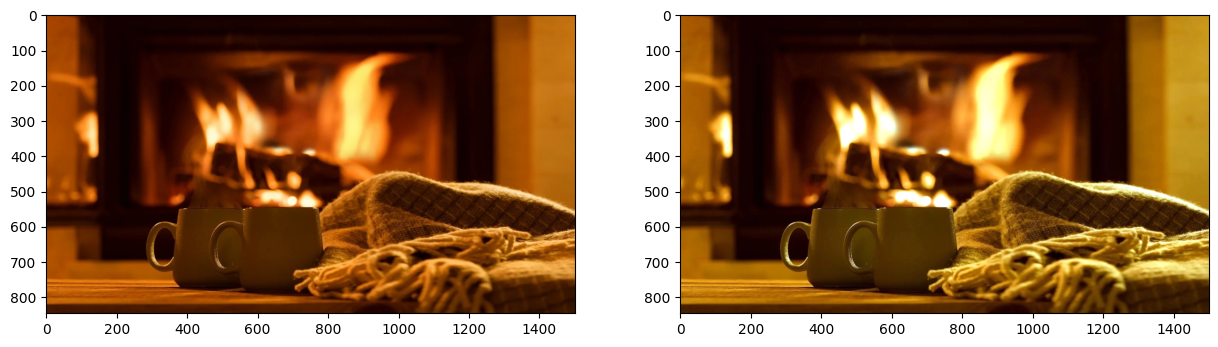

In [149]:
# Define white patch and the coefficients

# FOR ../data/cocoa+fireside.jpg
# row, col = 690, 525 # the best white-patch candidate according to ChatGPT - actually not the best 🤷‍♂️
# row, col = 220, 1392 # right wall middle
# row, col = 1, 1383 # right wall top
# row, col = 319, 869 # fireplace
row, col = 609, 479 # a reflection on the handle of a mug. no artifacts. IMHO Winner 👑
white = img[row, col, :]


coeffs = 255.0/white # kr, kg, kb

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

In [23]:
# Load your image
img = cv2.imread('../data/sea.jpg')
# img = cv2.imread('../data/lion-bw-animals-predator-preview.jpg')
# img = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg')
# img = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg')
# img = cv2.imread('../data/owl.png')
# img = cv2.imread('../data/lion-bw-animals-predator-preview.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = 
mean_g = 
mean_b = 

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = 
kg = 
kb = 

# Apply color balancing and generate the balanced image
balanced = 

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

SyntaxError: invalid syntax (361819990.py, line 6)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage at 0x234b6300790>)

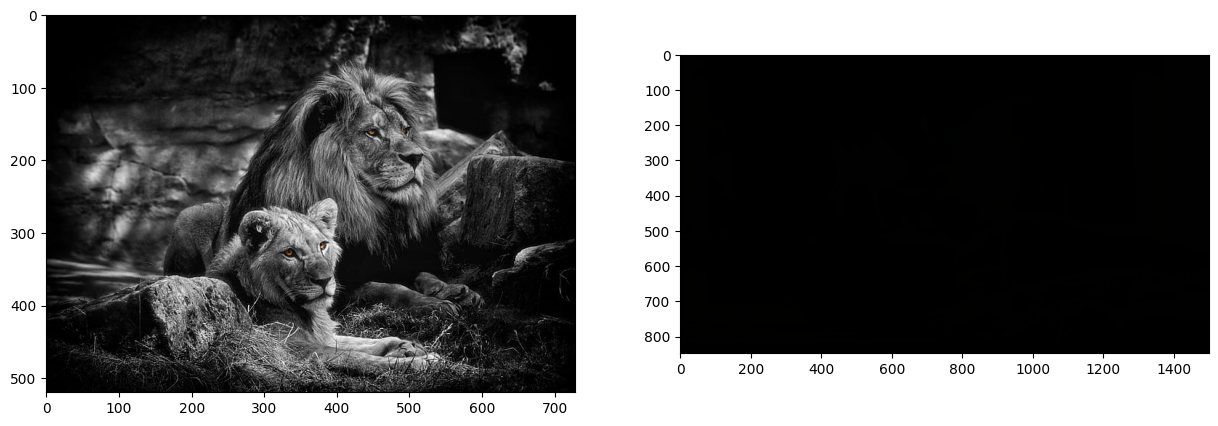

In [66]:
# Load your image
# img = cv2.imread('../data/sea.jpg')
# img = cv2.imread('../data/lion-bw-animals-predator-preview.jpg')
# img = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg')
# img = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg')
# img = cv2.imread('../data/owl.png')
img = cv2.imread('../data/lion-bw-animals-predator-preview.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
img_f = img.astype(np.float32)

max_r = img_f[..., 0].max()
max_g = img_f[..., 1].max()
max_b = img_f[..., 2].max()

# Apply scale-by-max balancing and generate the balanced image
balanced = np.clip(balanced, 0, 255).astype(np.uint8)


plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)